In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import jieba
import nltk
from nltk.corpus import stopwords
import re

In [3]:
# Load CSVs
df_cn = pd.read_csv('douban_reviews.csv')
df_en = pd.read_csv('imdb_review.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))

#load in Chinese stopwords
zh_stopwords = set(open('chinese_stopwords.txt', encoding='utf-8').read().split())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# Chinese preprocessing
def clean_chinese(text):
    text = re.sub(r"[^\u4e00-\u9fa5]", "", str(text))  # Keep only Chinese
    words = jieba.lcut(text)
    words = [word for word in words if word not in zh_stopwords]
    return ' '.join(words)

# English preprocessing
def clean_english(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in eng_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_cn['clean_comment'] = df_cn['review_text'].apply(clean_chinese)
df_en['clean_comment'] = df_en['comment'].apply(clean_english)

Building prefix dict from the default dictionary ...
Dumping model to file cache /var/folders/m_/hhg0dx_j62qbf4m6rdt4_3qc0000gn/T/jieba.cache
Loading model cost 0.262 seconds.
Prefix dict has been built successfully.


In [5]:
comments = df_cn["clean_comment"].dropna().tolist()

In [6]:
from sentence_transformers import SentenceTransformer

# Use a multilingual model or a specific Chinese one
model = SentenceTransformer("shibing624/text2vec-base-chinese")
# For more accurate results with Chinese: "shibing624/text2vec-base-chinese"

embeddings = model.encode(comments, show_progress_bar=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 96/96 [00:37<00:00,  2.56it/s]


In [22]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6  # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

df_cn['cluster'] = labels

In [17]:
!pip install BCEmbedding

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached BCEmbedding-0.1.5-py3-none-any.whl.metadata (32 kB)
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.15.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.7 kB)
  Using cached pyarrow-20.0.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (3.3 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
INFO: pip is looking at multiple versions of sentence-transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached sentence_transformers-4.0.2-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached sentence_transformers-4.0.0-

In [18]:
from BCEmbedding import EmbeddingModel

model = EmbeddingModel("maidalun1020/bce-embedding-base_v1")
embedding = model.encode(comments, lexicon_aware=True)

05/23/2025 22:28:34 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Loading from `maidalun1020/bce-embedding-base_v1`.
05/23/2025 22:28:34 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Execute device: cpu;	 gpu num: 0;	 use fp16: False;	 embedding pooling type: cls;	 trust remote code: False
Extract embeddings: 100%|██████████| 12/12 [21:36<00:00, 108.00s/it]


In [23]:
#print some random comments from each cluster
for cluster_num in sorted(df_cn['cluster'].unique()):
    print(f"\nCluster {cluster_num}:")
    sample_comments = df_cn[df_cn['cluster'] == cluster_num]['clean_comment'].sample(4, random_state=42)
    for comment in sample_comments:
        print(" -", comment)


Cluster 0:
 - 瞬息 全宇宙 口碑 看到 知道 结尾 爱来 拯救 电影 生活化 方式 讲述 大概 故事 一位 漂亮 能干 女性 年轻 不顾 家人 反对 嫁给 平庸 懦弱 男人 孩子 出生 生活 琐碎 家庭成员 性格 焦虑 母亲 无能 父亲 缺爱 孩子 奠定 养育 出 叛逆 心理 问题 人格障碍 孩子 最后 母亲 用爱 拯救 孩子 缓解 中年 危机 生活 变得 有序 和谐 起来 故事 基调 贴合 真实 中年人 生活 经济 压力 夫妻关系 赡养 老人 教育 孩子 现代 越来越 孩子 心理 问题 影片 宇宙 最高 维 宇宙 女儿 开发 过度 感知 过载 心智 脆弱 能力 超强 瞬息 全宇宙 接近 全知全能 越 容易 感到 虚无 黑化求 死 东亚 鸡娃们 父母 从小 以不输 起跑线 信条 接受 繁重 学习 教育 任务 优秀 脆弱 叛逆 宇宙 里 反派 女儿 用贝果 黑洞 毁灭 世界 其实 世界 女儿 元 宇宙 母亲 元 宇宙 一家人 元 宇宙 交集 元 宇宙 自然 影响 女儿 母亲 爱 恨 两个 屡屡 交锋 不断 推开 母亲 想 自杀 影片 出现 宇宙 中是 离家出走 宇宙 黑洞 悬崖 理解 成 自杀 想过 母亲 一块儿 要死 救 救 算了 别救 一起 死 似乎 有点像 回避 性 依恋 边缘型 人格障碍 母亲 女儿 经历 宇宙 间 不断 跳转 穿梭 拥有 瞬息 全宇宙 能力 同样 感受 虚无 懦弱 无能 父亲 善良 爱意 触动 母亲 其实 对应 宇宙 父亲 爱着 母亲 母亲 变得 柔软 力量 父亲 外公 一致 认为 女儿 无药 可救 之际 母亲 没有 想要 消灭 魔头 女儿 无条件 爱 坚持 放弃 拯救 女儿 生活 当中 何尝 妈妈 不爱 孩子 看不见 孩子 希望 女儿 成为 理想 女儿 总是 否定 女儿 女儿 要求 比较 严格 知道 给予 孩子 充足 耐心 爱 表达 多一点 信任 降低要求 不要 过分 挑剔 少 一点 焦虑 丈夫 认同 肯定 放慢 生活节奏 女儿 不会 回到 现实 问题 工作 交税 家务 上有老下有小 一系列 问题 解决 母亲 只能 变成 焦虑 女强人 贯穿 全篇 税务员 能够 感同身受 中年 女性 敌对 化为 抱团 取暖 其实 女儿 需要 妈妈 看见 不到 理解 起码 了解 接纳 尊重 爱 妈妈 女超人 平凡 普通 女超人 重新 选 我会 

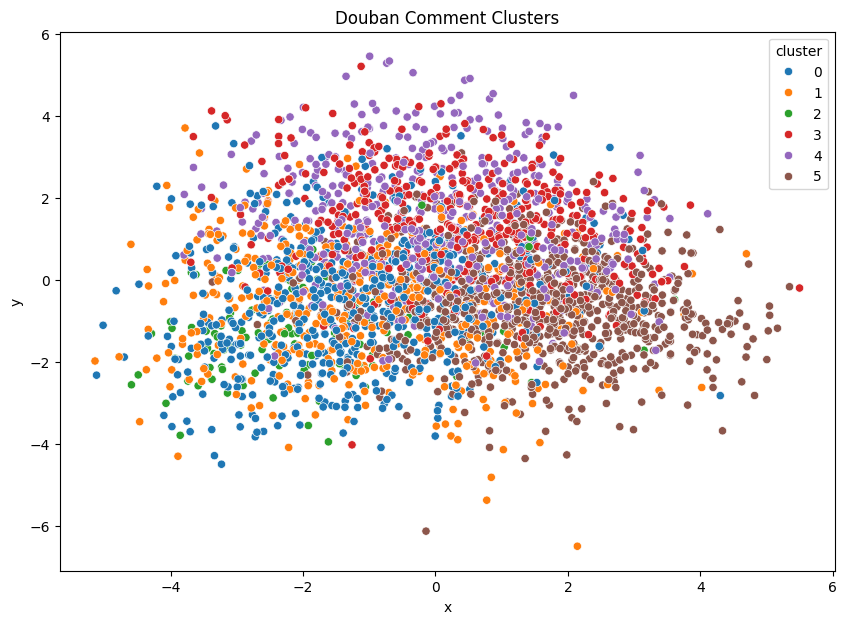

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df_cn['x'] = reduced[:, 0]
df_cn['y'] = reduced[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_cn, x='x', y='y', hue='cluster', palette='tab10')
plt.title("Douban Comment Clusters")
plt.show()

In [28]:
from keybert import KeyBERT

kw_model = KeyBERT(model)
for i in range(num_clusters):
    cluster_comments = df_cn[df_cn['cluster'] == i]['clean_comment'].tolist()
    joined = " ".join(cluster_comments)
    keywords = kw_model.extract_keywords(joined, top_n=5)
    print(f"Cluster {i} keywords:", keywords)

AttributeError: partially initialized module 'datasets' from '/Users/elimarx/miniconda3/lib/python3.13/site-packages/datasets/__init__.py' has no attribute 'utils' (most likely due to a circular import)